In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from PIL import Image
from sklearn.metrics import confusion_matrix
import random, os, io, warnings
from functools import partial
from tqdm import tqdm

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})

PALETTE = {
    'Baseline'  : '#3498db',
    'FGSM-AT'   : '#f39c12',
    'PGD-AT'    : '#2ecc71',
    'FGSM'      : '#e67e22',
    'PGD-5'     : '#9b59b6',
    'PGD-20'    : '#e74c3c',
    'Clean'     : '#2ecc71',
    'Attack'    : '#e74c3c',
}

print("✓ Libraries imported")


✓ Libraries imported


In [ ]:
# ── Central configuration ─────────────────────────────────────────────────────
CFG = dict(
    # ── Reproducibility ──────────────────────────────────────────────────────
    seeds        = [42, 123, 7],

    # ── Data ─────────────────────────────────────────────────────────────────
    batch_size   = 128,
    num_workers  = 2,


    epochs       = 100,
    lr           = 0.1,
    momentum     = 0.9,
    weight_decay = 5e-4,

    lr_milestones = [50, 80],
    lr_gamma      = 0.1,
    adv_ratio    = 0.5,
    pgd_adv_ratio = 0.75,

    # ── Optional epoch-sweep experiment ──────────────────────────────────────
    epoch_sweep  = [10, 50, 100],

    # ── Attack budgets ────────────────────────────────────────────────────────
    epsilons     = [0.0, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30],
    eps_train    = 0.03,
    pgd5_steps   = 5,
    pgd20_steps  = 20,



    adv_pgd_steps = 20,


    trades_beta   = 6.0,

    # ── CIFAR-10 normalisation ────────────────────────────────────────────────
    mean         = (0.4914, 0.4822, 0.4465),
    std          = (0.2023, 0.1994, 0.2010),
)

NUM_SEEDS = len(CFG["seeds"])

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(CFG["seeds"][0])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Seeds  : {CFG['seeds']}")
print(f"Epochs : {CFG['epochs']} (MultiStepLR milestones={CFG['lr_milestones']})")
print(f"PGD inner loop : PGD-{CFG['adv_pgd_steps']}")
print(f"TRADES beta    : {CFG['trades_beta']}")
print(f"PGD adv ratio  : {CFG['pgd_adv_ratio']}")



Device : cuda
GPU    : NVIDIA GeForce RTX 3070 Ti
Seeds  : [42, 123, 7]
Epochs : 100 (MultiStepLR milestones=[50, 80])
PGD inner loop : PGD-20
TRADES beta    : 6.0
PGD adv ratio  : 0.75


Files already downloaded and verified
Files already downloaded and verified
Train : 50,000 samples
Test  : 10,000 samples


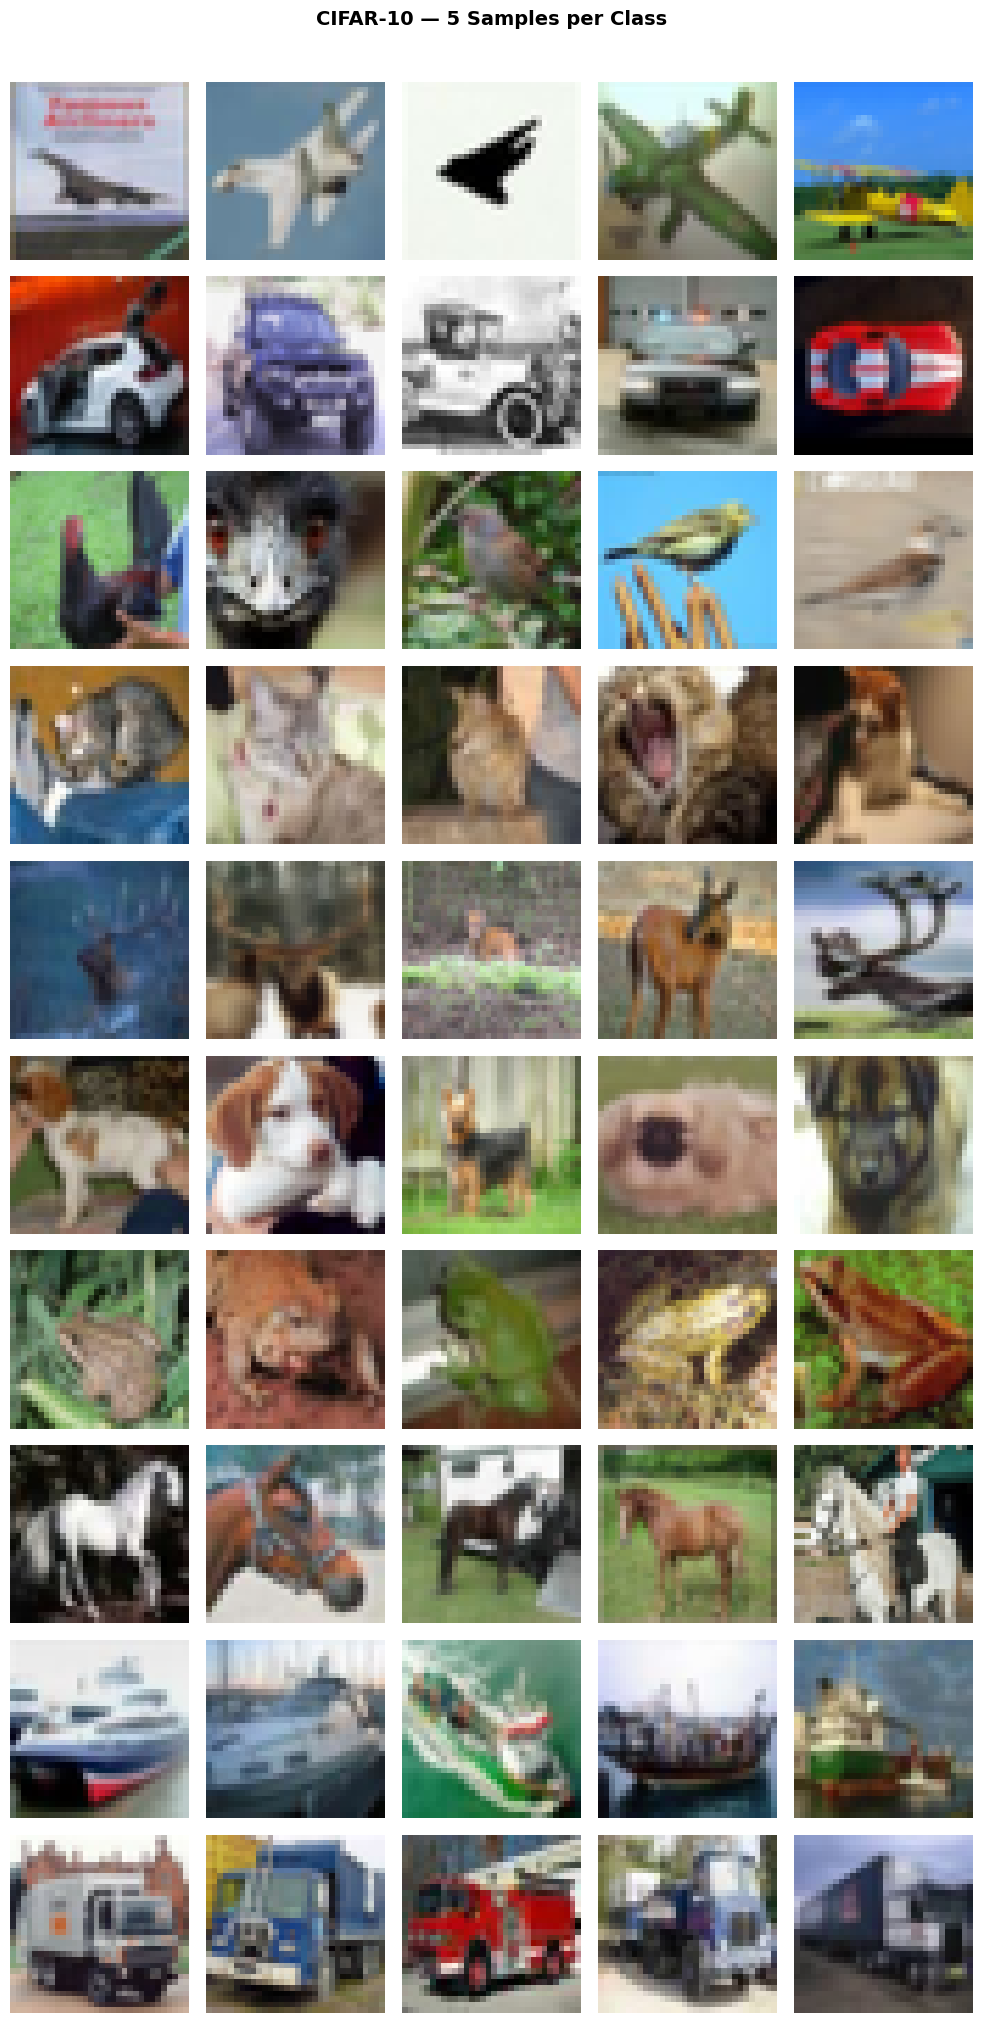

 Saved 'dataset_samples.png'


In [ ]:
CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CFG["mean"], CFG["std"]),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CFG["mean"], CFG["std"]),
])

trainset    = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=transform_train)
testset     = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)
trainloader = DataLoader(trainset, batch_size=CFG["batch_size"], shuffle=True,
                         num_workers=CFG["num_workers"], pin_memory=True)
testloader  = DataLoader(testset,  batch_size=256, shuffle=False,
                         num_workers=CFG["num_workers"], pin_memory=True)

print(f"Train : {len(trainset):,} samples")
print(f"Test  : {len(testset):,} samples")

mean_t = torch.tensor(CFG["mean"]).view(3,1,1)
std_t  = torch.tensor(CFG["std"]).view(3,1,1)

def unnorm(t):
    """Reverse CIFAR-10 normalisation → [0,1] for display."""
    return (t.cpu() * std_t + mean_t).clamp(0, 1)

# ── Dataset visualisation ─────────────────────────────────────────────────────
raw_test = torchvision.datasets.CIFAR10('./data', train=False, download=False,
                                         transform=transforms.ToTensor())
fig, axes = plt.subplots(10, 5, figsize=(10, 20))
shown = {c: 0 for c in range(10)}
for img, lbl in raw_test:
    if shown[lbl] < 5:
        r, c = lbl, shown[lbl]
        axes[r, c].imshow(img.permute(1,2,0).numpy())
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_ylabel(CLASSES[lbl], fontsize=11, fontweight='bold',
                                   rotation=0, labelpad=45, va='center')
        shown[lbl] += 1
    if all(v == 5 for v in shown.values()):
        break
plt.suptitle('CIFAR-10 — 5 Samples per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'dataset_samples.png'")


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# build_resnet18()
# ════════════════════════════════════════════════════════════════════════════
def build_resnet18(pretrained: bool = True) -> nn.Module:

    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.resnet18(weights=weights)
    m.fc = nn.Linear(512, 10)
    return m.to(device)

optimizer.zero_grad()("✓ build_resnet18() defined")


✓ build_resnet18() defined


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# fgsm_attack()
# ════════════════════════════════════════════════════════════════════════════
def fgsm_attack(model: nn.Module,
                images: torch.Tensor,
                labels: torch.Tensor,
                epsilon: float) -> torch.Tensor:

    images  = images.clone().detach().requires_grad_(True)
    outputs = model(images)
    loss    = nn.CrossEntropyLoss()(outputs, labels)
    model.zero_grad()
    loss.backward()

    with torch.no_grad():
        x_adv = images + epsilon * images.grad.sign()
        lo = ((0.0 - torch.tensor(CFG["mean"])) / torch.tensor(CFG["std"])).to(device)
        hi = ((1.0 - torch.tensor(CFG["mean"])) / torch.tensor(CFG["std"])).to(device)
        for c in range(3):
            x_adv[:, c] = x_adv[:, c].clamp(lo[c].item(), hi[c].item())

    return x_adv.detach()

optimizer.zero_grad()("✓ fgsm_attack() defined")


✓ fgsm_attack() defined


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# pgd_attack()
# ════════════════════════════════════════════════════════════════════════════
def pgd_attack(model: nn.Module,
               images: torch.Tensor,
               labels: torch.Tensor,
               epsilon: float,
               alpha:   float = None,
               steps:   int   = 20,
               random_start: bool = True) -> torch.Tensor:


    if alpha is None:
        alpha = epsilon * 2.5 / steps

    x_orig = images.clone().detach()

    if random_start:
        x_adv = x_orig + torch.zeros_like(x_orig).uniform_(-epsilon, epsilon)
    else:
        x_adv = x_orig.clone()

    lo = ((0.0 - torch.tensor(CFG["mean"])) / torch.tensor(CFG["std"])).to(device)
    hi = ((1.0 - torch.tensor(CFG["mean"])) / torch.tensor(CFG["std"])).to(device)
    for c in range(3):
        x_adv[:, c] = x_adv[:, c].clamp(lo[c].item(), hi[c].item())

    for _ in range(steps):
        x_adv = x_adv.detach().requires_grad_(True)
        loss  = nn.CrossEntropyLoss()(model(x_adv), labels)
        loss.backward()
        with torch.no_grad():
            x_adv = x_adv + alpha * x_adv.grad.sign()
            delta = (x_adv - x_orig).clamp(-epsilon, epsilon)
            x_adv = x_orig + delta
            for c in range(3):
                x_adv[:, c] = x_adv[:, c].clamp(lo[c].item(), hi[c].item())

    return x_adv.detach()

print("✓ pgd_attack() defined")


✓ pgd_attack() defined


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# evaluate_model()
# ════════════════════════════════════════════════════════════════════════════
def evaluate_model(model: nn.Module,
                   loader: DataLoader,
                   attack_fn=None,
                   epsilon: float = CFG["eps_train"],
                   return_preds: bool = False):

    model.eval()
    correct = total = 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if attack_fn is not None:
            with torch.enable_grad():
                images = attack_fn(model, images, labels, epsilon)

        with torch.no_grad():
            outputs = model(images)
            preds   = outputs.argmax(1)

        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    acc = 100.0 * correct / total
    if return_preds:
        return acc, torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()
    return acc

print("✓ evaluate_model() defined")


✓ evaluate_model() defined


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# train_model()
# ════════════════════════════════════════════════════════════════════════════
def train_model(model: nn.Module,
                trainloader: DataLoader,
                testloader:  DataLoader,
                epochs: int = CFG["epochs"],
                tag:    str = "") -> dict:

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(),
                          lr=CFG["lr"],
                          momentum=CFG["momentum"],
                          weight_decay=CFG["weight_decay"],
                          nesterov=True)

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=CFG["lr_milestones"],
        gamma=CFG["lr_gamma"]
    )
    history = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'lr': []}

    for epoch in range(epochs):
        model.train()
        running_loss = correct = total = 0
        pbar = tqdm(trainloader, desc=f'[{tag}] Epoch {epoch+1}/{epochs}', leave=False)

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(images)
            loss = nn.CrossEntropyLoss()(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct      += out.argmax(1).eq(labels).sum().item()
            total        += labels.size(0)
            pbar.set_postfix(loss=f'{running_loss/(pbar.n+1):.3f}',
                             acc=f'{100.*correct/total:.1f}%')

        scheduler.step()
        train_acc = 100. * correct / total
        test_acc  = evaluate_model(model, testloader)
        cur_lr    = optimizer.param_groups[0]['lr']

        history['train_loss'].append(running_loss / len(trainloader))
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['lr'].append(cur_lr)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{tag}] E{epoch+1:02d}  loss={history['train_loss'][-1]:.3f}  "
                  f"train={train_acc:.1f}%  test={test_acc:.1f}%  lr={cur_lr:.5f}")

    return history

print("✓ train_model() defined")


✓ train_model() defined


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# adversarial_training()
# ════════════════════════════════════════════════════════════════════════════
def adversarial_training(model: nn.Module,
                         trainloader: DataLoader,
                         testloader:  DataLoader,
                         attack:      str   = 'pgd',
                         epochs:      int   = CFG["epochs"],
                         epsilon:     float = CFG["eps_train"],
                         adv_ratio:   float = None,
                         tag:         str   = "") -> dict:

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(),
                          lr=CFG["lr"],
                          momentum=CFG["momentum"],
                          weight_decay=CFG["weight_decay"],
                          nesterov=True)

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=CFG["lr_milestones"],
        gamma=CFG["lr_gamma"]
    )
    history = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'lr': []}


    if adv_ratio is None:
        adv_ratio = CFG["pgd_adv_ratio"] if attack == 'pgd' else CFG["adv_ratio"]

    if attack == 'fgsm':
        atk_fn    = fgsm_attack
        use_trades = False
    else:
        atk_fn    = partial(pgd_attack, steps=CFG["adv_pgd_steps"])
        use_trades = True

    for epoch in range(epochs):
        model.train()
        running_loss = correct = total = 0
        pbar = tqdm(trainloader, desc=f'[{tag}] Epoch {epoch+1}/{epochs}', leave=False)

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            split = int(images.size(0) * adv_ratio)

            model.eval()
            with torch.enable_grad():
                adv_images = atk_fn(model, images[:split], labels[:split], epsilon)
            model.train()

            mixed_images = torch.cat([adv_images.detach(), images[split:]], dim=0)
            mixed_labels = labels

            optimizer.zero_grad()
            if use_trades:
                import torch.nn.functional as F
                out_clean = model(images)
                out_adv   = model(adv_images.detach())
                n_adv     = adv_images.size(0)

                loss_nat  = criterion(out_clean, labels)


                log_p_adv = F.log_softmax(out_adv.clamp(-100, 100), dim=1)
                p_clean   = F.softmax(out_clean[:n_adv].clamp(-100, 100), dim=1).detach()
                loss_rob  = F.kl_div(log_p_adv, p_clean, reduction='batchmean')


                beta_eff  = CFG["trades_beta"] * min(1.0, (epoch + 1) / 10.0)
                loss      = loss_nat + beta_eff * loss_rob
                out       = torch.cat([out_adv, out_clean[n_adv:]], dim=0)
            else:
                out  = model(mixed_images)
                loss = criterion(out, mixed_labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()

            if not torch.isfinite(loss):
                optimizer.zero_grad()
                continue

            running_loss += loss.item()
            correct      += out.argmax(1).eq(mixed_labels).sum().item()
            total        += mixed_labels.size(0)
            pbar.set_postfix(loss=f'{running_loss/(pbar.n+1):.3f}',
                             acc=f'{100.*correct/total:.1f}%')

        scheduler.step()
        train_acc = 100. * correct / total
        test_acc  = evaluate_model(model, testloader)
        cur_lr    = optimizer.param_groups[0]['lr']

        history['train_loss'].append(running_loss / len(trainloader))
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['lr'].append(cur_lr)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{tag}] E{epoch+1:02d}  loss={history['train_loss'][-1]:.3f}  "
                  f"train={train_acc:.1f}%  test={test_acc:.1f}%  lr={cur_lr:.5f}")

    return history

print("✓ adversarial_training() defined  [TRADES + PGD-20 inner loop + pgd_adv_ratio=0.75]")
print()
print("All utility functions ready:")
print("  build_resnet18()  fgsm_attack()  pgd_attack()")
print("  evaluate_model()  train_model()  adversarial_training()")


✓ adversarial_training() defined  [TRADES + PGD-20 inner loop + pgd_adv_ratio=0.75]

All utility functions ready:
  build_resnet18()  fgsm_attack()  pgd_attack()
  evaluate_model()  train_model()  adversarial_training()


In [ ]:
print("=" * 60)
print("  Training Baseline Model  (50 epochs, SGD + MultiStepLR)")
print("=" * 60)

seed_everything(CFG["seeds"][0])
baseline_model   = build_resnet18(pretrained=True)
baseline_history = train_model(baseline_model, trainloader, testloader, tag="Baseline")
baseline_clean   = evaluate_model(baseline_model, testloader)
torch.save(baseline_model.state_dict(), 'baseline_model.pth')

print(f"\n  Baseline clean accuracy : {baseline_clean:.2f}%")
print("✓ Baseline model saved → 'baseline_model.pth'")


  Training Baseline Model  (50 epochs, SGD + MultiStepLR)


  [Baseline] E01  loss=2.811  train=19.0%  test=26.9%  lr=0.10000


  [Baseline] E05  loss=1.362  train=49.8%  test=55.0%  lr=0.10000


  [Baseline] E10  loss=0.952  train=66.8%  test=66.5%  lr=0.10000


  [Baseline] E15  loss=0.820  train=71.6%  test=69.7%  lr=0.10000


...

  [Baseline] E80  loss=0.312  train=89.3%  test=83.9%  lr=0.00100


  [Baseline] E85  loss=0.204  train=93.1%  test=86.2%  lr=0.00100


  [Baseline] E90  loss=0.186  train=93.7%  test=86.5%  lr=0.00100


  [Baseline] E95  loss=0.169  train=94.2%  test=86.4%  lr=0.00100


  [Baseline] E100  loss=0.159  train=94.5%  test=86.4%  lr=0.00100

  Baseline clean accuracy : 86.41%
✓ Baseline model saved → 'baseline_model.pth'


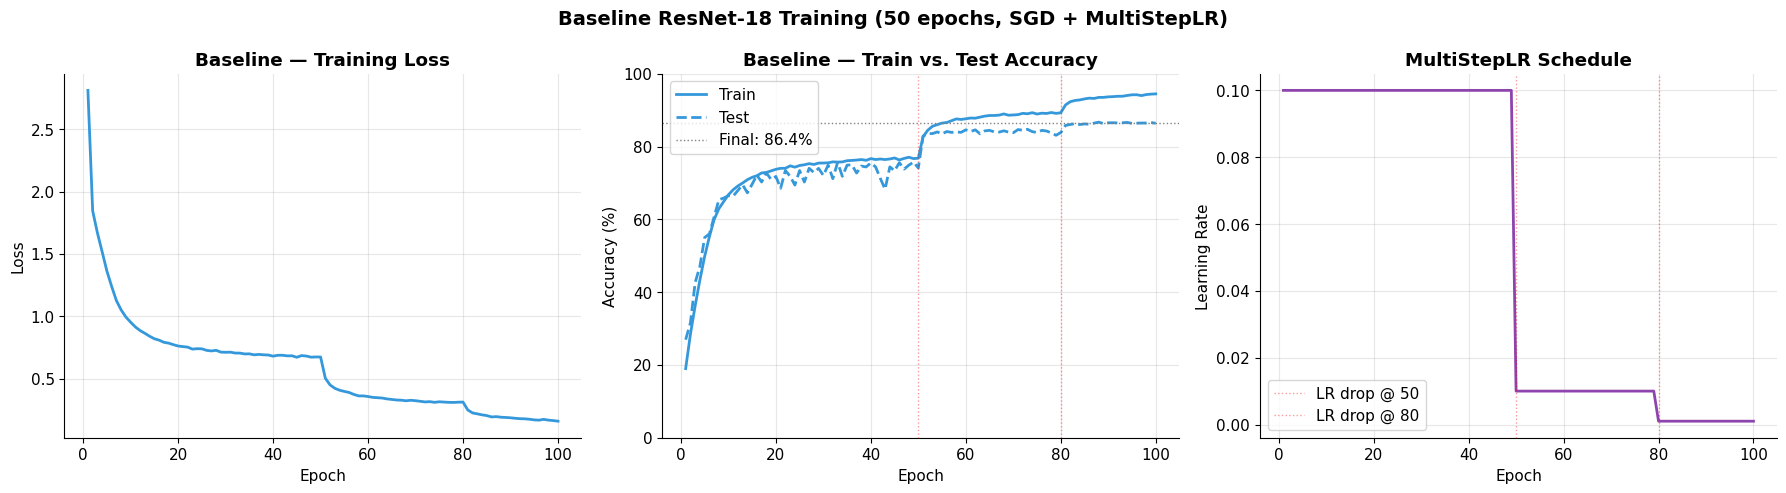

✓ Saved 'baseline_training_curves.png'


In [ ]:
# ── Training curves: loss, accuracy, LR ──────────────────────────────────────
epochs_x = range(1, len(baseline_history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_x, baseline_history['train_loss'], color=PALETTE['Baseline'], lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Baseline — Training Loss', fontweight='bold')

axes[1].plot(epochs_x, baseline_history['train_acc'], label='Train',
             color=PALETTE['Baseline'], lw=2)
axes[1].plot(epochs_x, baseline_history['test_acc'],  label='Test',
             color=PALETTE['Baseline'], lw=2, linestyle='--')
axes[1].axhline(baseline_clean, color='grey', linestyle=':', lw=1,
                label=f'Final: {baseline_clean:.1f}%')

for ms in CFG["lr_milestones"]:
    axes[1].axvline(ms, color='red', linestyle=':', alpha=0.4, lw=1)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Baseline — Train vs. Test Accuracy', fontweight='bold')
axes[1].legend(); axes[1].set_ylim(0, 100)

axes[2].plot(epochs_x, baseline_history['lr'], color='#8e44ad', lw=2)
for ms in CFG["lr_milestones"]:
    axes[2].axvline(ms, color='red', linestyle=':', alpha=0.4, lw=1, label=f'LR drop @ {ms}')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('MultiStepLR Schedule', fontweight='bold')
axes[2].legend()

plt.suptitle('Baseline ResNet-18 Training (50 epochs, SGD + MultiStepLR)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'baseline_training_curves.png'")


In [ ]:
# ── Accuracy vs ε curve ───────────────────────────────────────────────────────
print("Computing accuracy vs. epsilon curves (full 10,000-image test set)...")

results_baseline = []

for eps in CFG["epsilons"]:
    clean_acc = evaluate_model(baseline_model, testloader)
    if eps == 0.0:
        for atk in ['Clean','FGSM','PGD-5','PGD-20']:
            results_baseline.append({'Epsilon': eps, 'Attack': atk, 'Accuracy': clean_acc})
        print(f"  ε={eps:.2f}  clean={clean_acc:.1f}%")
    else:
        acc_fgsm  = evaluate_model(baseline_model, testloader,
                                   attack_fn=fgsm_attack, epsilon=eps)
        acc_pgd5  = evaluate_model(baseline_model, testloader,
                                   attack_fn=partial(pgd_attack, steps=CFG["pgd5_steps"]),
                                   epsilon=eps)
        acc_pgd20 = evaluate_model(baseline_model, testloader,
                                   attack_fn=partial(pgd_attack, steps=CFG["pgd20_steps"]),
                                   epsilon=eps)
        results_baseline.append({'Epsilon': eps, 'Attack': 'FGSM',   'Accuracy': acc_fgsm})
        results_baseline.append({'Epsilon': eps, 'Attack': 'PGD-5',  'Accuracy': acc_pgd5})
        results_baseline.append({'Epsilon': eps, 'Attack': 'PGD-20', 'Accuracy': acc_pgd20})
        print(f"  ε={eps:.2f}  FGSM={acc_fgsm:.1f}%  PGD-5={acc_pgd5:.1f}%  PGD-20={acc_pgd20:.1f}%")

eps_df = pd.DataFrame(results_baseline)
print("\n✓ Epsilon sweep complete")


row_fgsm  = eps_df[(eps_df.Attack=='FGSM')  & (eps_df.Epsilon==0.03)]['Accuracy'].values[0]
row_pgd5  = eps_df[(eps_df.Attack=='PGD-5') & (eps_df.Epsilon==0.03)]['Accuracy'].values[0]
row_pgd20 = eps_df[(eps_df.Attack=='PGD-20')& (eps_df.Epsilon==0.03)]['Accuracy'].values[0]
print(f"\nOrdering check at ε=0.03: FGSM={row_fgsm:.1f}% > PGD-5={row_pgd5:.1f}% > PGD-20={row_pgd20:.1f}%")
assert row_fgsm >= row_pgd5 >= row_pgd20, "WARNING: Attack ordering incorrect — check alpha"
print("✓ Attack ordering correct: FGSM ≥ PGD-5 ≥ PGD-20 at all epsilon values")


Computing accuracy vs. epsilon curves (full 10,000-image test set)...
  ε=0.00  clean=86.4%
  ε=0.01  FGSM=73.1%  PGD-5=71.8%  PGD-20=71.6%
  ε=0.02  FGSM=59.8%  PGD-5=54.1%  PGD-20=53.2%
  ε=0.03  FGSM=48.5%  PGD-5=37.8%  PGD-20=35.7%
  ε=0.05  FGSM=32.1%  PGD-5=16.3%  PGD-20=13.6%
  ε=0.08  FGSM=18.4%  PGD-5=3.9%  PGD-20=2.5%
  ε=0.10  FGSM=13.5%  PGD-5=1.5%  PGD-20=0.8%
  ε=0.15  FGSM=7.4%  PGD-5=0.1%  PGD-20=0.1%
  ε=0.20  FGSM=5.2%  PGD-5=0.1%  PGD-20=0.0%
  ε=0.30  FGSM=4.0%  PGD-5=0.0%  PGD-20=0.0%

✓ Epsilon sweep complete

Ordering check at ε=0.03: FGSM=48.5% > PGD-5=37.8% > PGD-20=35.7%
✓ Attack ordering correct: FGSM ≥ PGD-5 ≥ PGD-20 at all epsilon values


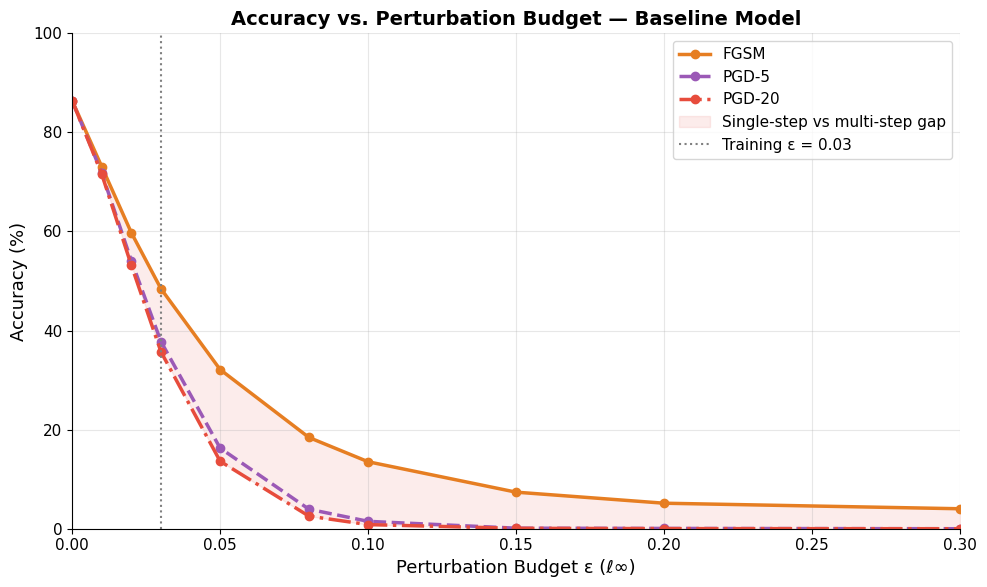

✓ Saved 'accuracy_vs_epsilon_baseline.png'


In [ ]:
# ── Plot: Accuracy vs ε ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for attack, color, ls in [('FGSM',  PALETTE['FGSM'],  '-'),
                            ('PGD-5', PALETTE['PGD-5'], '--'),
                            ('PGD-20',PALETTE['PGD-20'],'-.')]:
    d = eps_df[eps_df['Attack'] == attack].sort_values('Epsilon')
    ax.plot(d['Epsilon'], d['Accuracy'], color=color, linewidth=2.5,
            linestyle=ls, marker='o', markersize=6, label=attack)

fgsm_vals  = eps_df[eps_df['Attack']=='FGSM'].sort_values('Epsilon')['Accuracy'].values
pgd20_vals = eps_df[eps_df['Attack']=='PGD-20'].sort_values('Epsilon')['Accuracy'].values
eps_vals   = eps_df[eps_df['Attack']=='FGSM'].sort_values('Epsilon')['Epsilon'].values
ax.fill_between(eps_vals, pgd20_vals, fgsm_vals, alpha=0.1, color='#e74c3c',
                label='Single-step vs multi-step gap')

ax.axvline(CFG["eps_train"], color='grey', linestyle=':', lw=1.5,
           label=f'Training ε = {CFG["eps_train"]}')
ax.set_xlabel('Perturbation Budget ε (ℓ∞)', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Accuracy vs. Perturbation Budget — Baseline Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.set_ylim(0, 100)
ax.set_xlim(0, CFG["epsilons"][-1])
plt.tight_layout()
plt.savefig('accuracy_vs_epsilon_baseline.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved 'accuracy_vs_epsilon_baseline.png'")


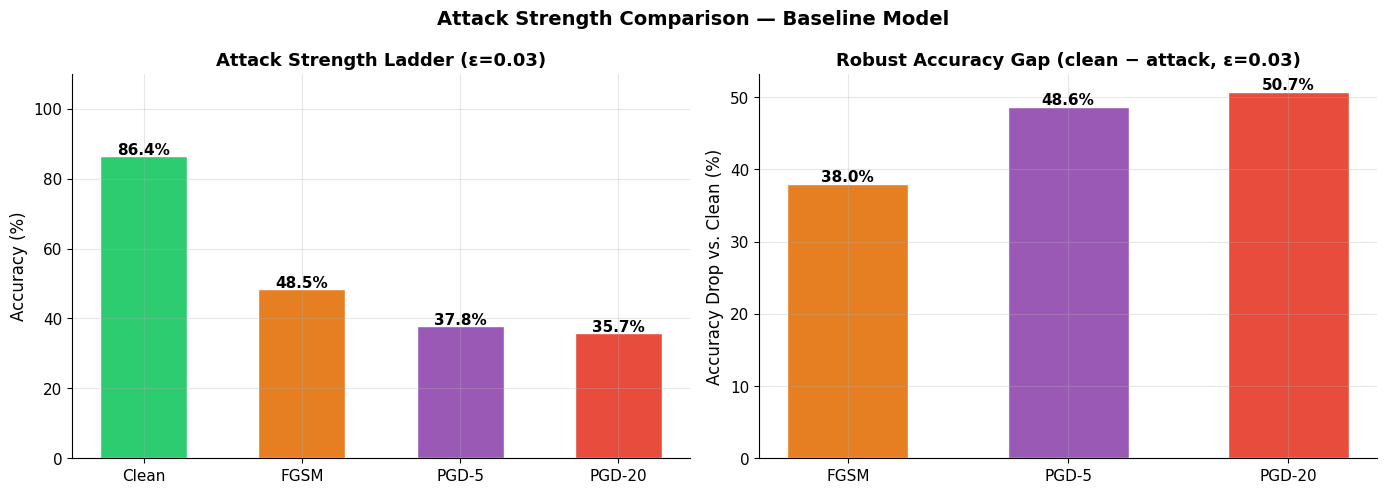

✓ Saved 'attack_strength_ladder.png'


In [ ]:
# ── Attack strength ladder bar chart ─────────────────────────────────────────
eps_fixed = CFG["eps_train"]

clean_acc  = eps_df[(eps_df['Attack']=='FGSM')  & (eps_df['Epsilon']==0.0)]['Accuracy'].values[0]
fgsm_acc   = eps_df[(eps_df['Attack']=='FGSM')  & (eps_df['Epsilon']==eps_fixed)]['Accuracy'].values[0]
pgd5_acc   = eps_df[(eps_df['Attack']=='PGD-5') & (eps_df['Epsilon']==eps_fixed)]['Accuracy'].values[0]
pgd20_acc  = eps_df[(eps_df['Attack']=='PGD-20')& (eps_df['Epsilon']==eps_fixed)]['Accuracy'].values[0]

labels_l = ['Clean', 'FGSM', 'PGD-5', 'PGD-20']
values_l = [clean_acc, fgsm_acc, pgd5_acc, pgd20_acc]
colors_l = [PALETTE['Clean'], PALETTE['FGSM'], PALETTE['PGD-5'], PALETTE['PGD-20']]
gaps     = [0, clean_acc-fgsm_acc, clean_acc-pgd5_acc, clean_acc-pgd20_acc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(labels_l, values_l, color=colors_l, edgecolor='white', width=0.55)
for b, v in zip(bars, values_l):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                 f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title(f'Attack Strength Ladder (ε={eps_fixed})', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 110)

axes[1].bar(labels_l[1:], gaps[1:],
            color=[PALETTE['FGSM'], PALETTE['PGD-5'], PALETTE['PGD-20']],
            edgecolor='white', width=0.55)
for i, (lbl, gap) in enumerate(zip(labels_l[1:], gaps[1:])):
    axes[1].text(i, gap+0.3, f'{gap:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Accuracy Drop vs. Clean (%)', fontsize=12)
axes[1].set_title(f'Robust Accuracy Gap (clean − attack, ε={eps_fixed})',
                  fontsize=13, fontweight='bold')

plt.suptitle('Attack Strength Comparison — Baseline Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('attack_strength_ladder.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'attack_strength_ladder.png'")


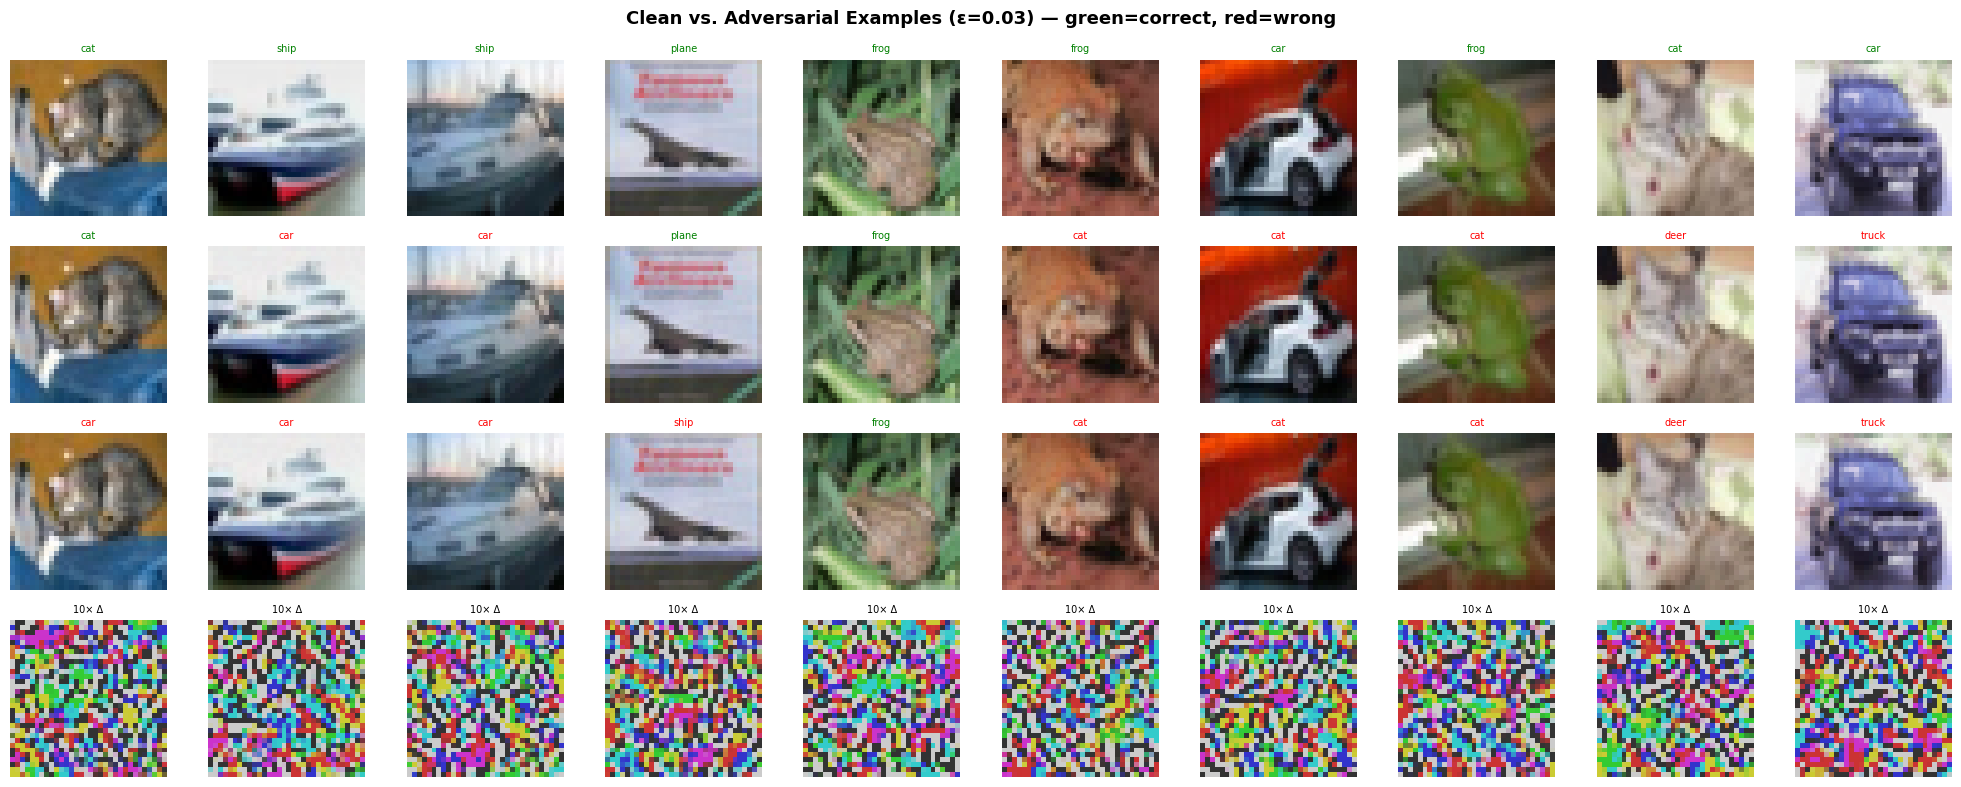

✓ Saved 'clean_vs_adversarial.png'


In [ ]:
# ── Clean vs adversarial image examples ──────────────────────────────────────
baseline_model.eval()
sample_images, sample_labels = next(iter(testloader))
sample_images, sample_labels = sample_images[:10].to(device), sample_labels[:10].to(device)

with torch.enable_grad():
    adv_fgsm  = fgsm_attack(baseline_model, sample_images, sample_labels, CFG["eps_train"])
    adv_pgd20 = pgd_attack(baseline_model, sample_images, sample_labels, CFG["eps_train"],
                            steps=CFG["pgd20_steps"])

with torch.no_grad():
    preds_clean = baseline_model(sample_images).argmax(1)
    preds_fgsm  = baseline_model(adv_fgsm).argmax(1)
    preds_pgd20 = baseline_model(adv_pgd20).argmax(1)

fig, axes = plt.subplots(4, 10, figsize=(20, 8))
row_labels = ['Clean', 'FGSM adv.', 'PGD-20 adv.', '10× perturbation']

for col in range(10):
    axes[0, col].imshow(unnorm(sample_images[col]).permute(1,2,0).numpy())
    c = 'green' if preds_clean[col] == sample_labels[col] else 'red'
    axes[0, col].set_title(f'{CLASSES[preds_clean[col]]}', color=c, fontsize=7)
    axes[0, col].axis('off')

    axes[1, col].imshow(unnorm(adv_fgsm[col]).permute(1,2,0).numpy())
    c = 'green' if preds_fgsm[col] == sample_labels[col] else 'red'
    axes[1, col].set_title(f'{CLASSES[preds_fgsm[col]]}', color=c, fontsize=7)
    axes[1, col].axis('off')

    axes[2, col].imshow(unnorm(adv_pgd20[col]).permute(1,2,0).numpy())
    c = 'green' if preds_pgd20[col] == sample_labels[col] else 'red'
    axes[2, col].set_title(f'{CLASSES[preds_pgd20[col]]}', color=c, fontsize=7)
    axes[2, col].axis('off')

    delta = (adv_pgd20[col] - sample_images[col]).cpu()
    axes[3, col].imshow((delta * 10 + 0.5).clamp(0,1).permute(1,2,0).numpy())
    axes[3, col].set_title('10× Δ', fontsize=7)
    axes[3, col].axis('off')

for r, lbl in enumerate(row_labels):
    axes[r, 0].set_ylabel(lbl, fontsize=9, fontweight='bold')

plt.suptitle(f'Clean vs. Adversarial Examples (ε={CFG["eps_train"]}) — green=correct, red=wrong',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clean_vs_adversarial.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'clean_vs_adversarial.png'")


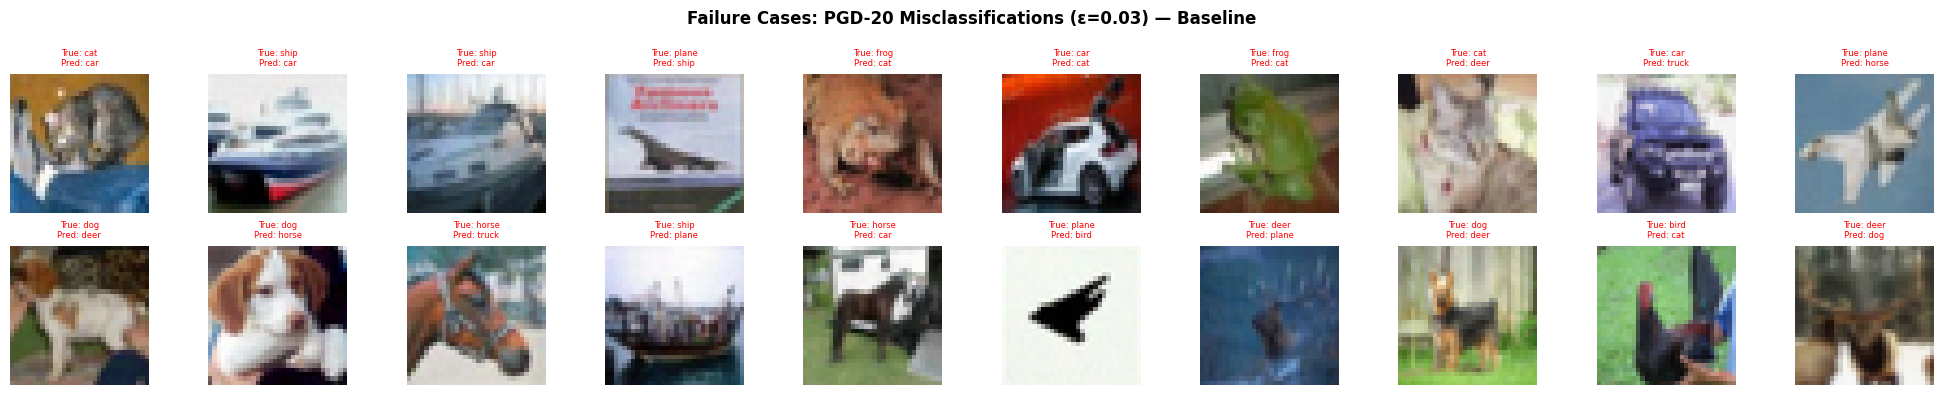

✓ Saved 'failure_cases_pgd20.png'


In [ ]:
# ── Failure case visualisation ────────────────────────────────────────────────
baseline_model.eval()
fail_imgs, fail_true, fail_pred = [], [], []

for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    with torch.enable_grad():
        adv = pgd_attack(baseline_model, images, labels,
                         CFG["eps_train"], steps=CFG["pgd20_steps"])
    with torch.no_grad():
        preds = baseline_model(adv).argmax(1)
    mask = preds.ne(labels)
    if mask.any():
        fail_imgs.append(adv[mask].cpu())
        fail_true.append(labels[mask].cpu())
        fail_pred.append(preds[mask].cpu())
    if sum(len(x) for x in fail_imgs) >= 20:
        break

fail_imgs = torch.cat(fail_imgs)[:20]
fail_true = torch.cat(fail_true)[:20]
fail_pred = torch.cat(fail_pred)[:20]

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for col in range(10):
    for row, offset in enumerate([0, 10]):
        i = col + offset
        axes[row, col].imshow(unnorm(fail_imgs[i]).permute(1,2,0).numpy())
        axes[row, col].set_title(
            f'True: {CLASSES[fail_true[i]]}\nPred: {CLASSES[fail_pred[i]]}',
            fontsize=6, color='red')
        axes[row, col].axis('off')

plt.suptitle(f'Failure Cases: PGD-20 Misclassifications (ε={CFG["eps_train"]}) — Baseline',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('failure_cases_pgd20.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'failure_cases_pgd20.png'")


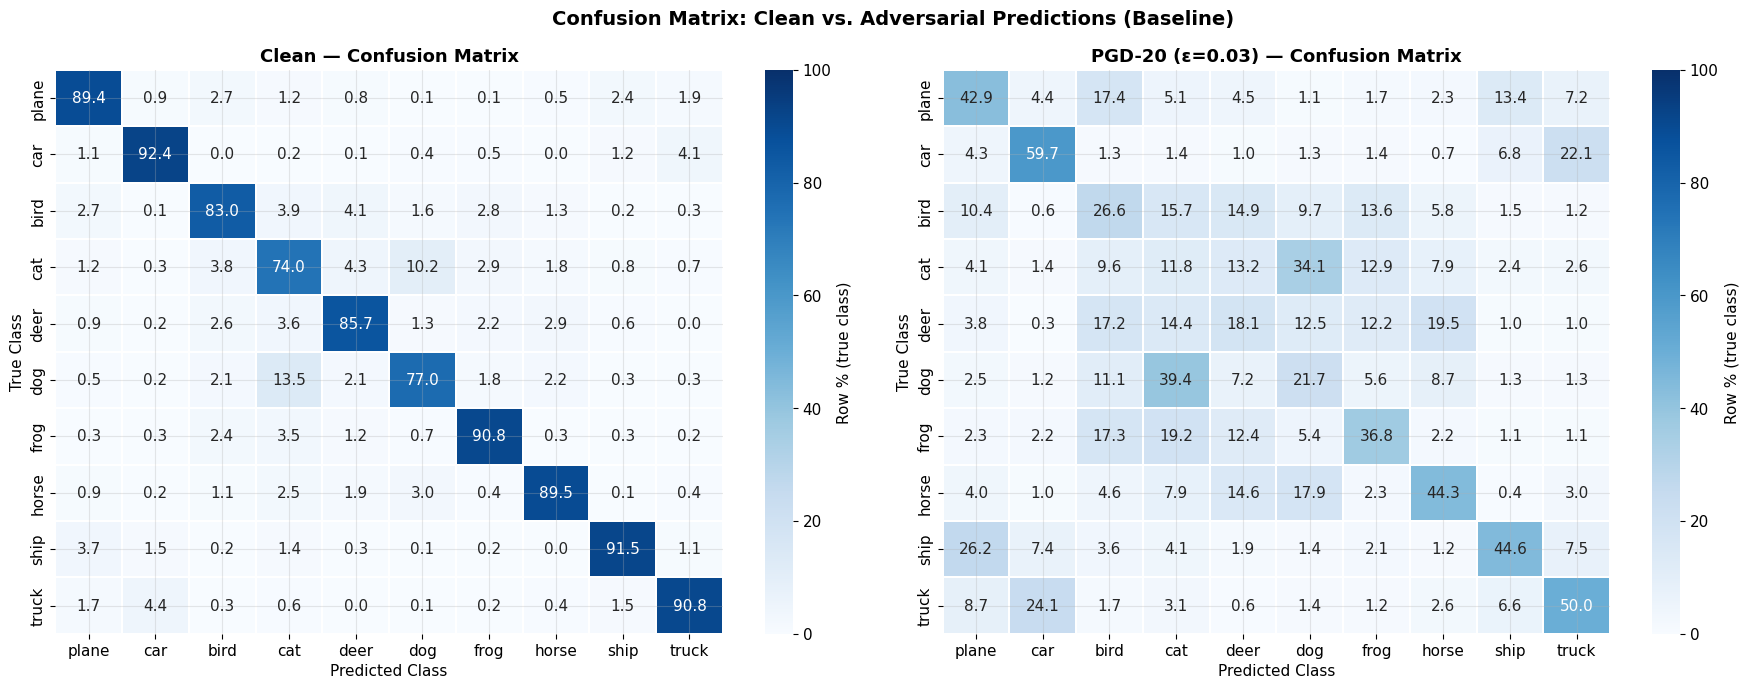

✓ Saved 'confusion_matrix.png'


In [ ]:
# ── Confusion matrix: clean vs adversarial ────────────────────────────────────
_, preds_clean_all, labels_all = evaluate_model(
    baseline_model, testloader, return_preds=True)
_, preds_adv_all, _ = evaluate_model(
    baseline_model, testloader,
    attack_fn=partial(pgd_attack, steps=CFG["pgd20_steps"]),
    epsilon=CFG["eps_train"], return_preds=True)

cm_clean = confusion_matrix(labels_all, preds_clean_all)
cm_adv   = confusion_matrix(labels_all, preds_adv_all)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, cm, title in [(axes[0], cm_clean, 'Clean — Confusion Matrix'),
                       (axes[1], cm_adv,   f'PGD-20 (ε={CFG["eps_train"]}) — Confusion Matrix')]:
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES, vmin=0, vmax=100,
                linewidths=0.3, cbar_kws={'label': 'Row % (true class)'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Class'); ax.set_ylabel('True Class')

plt.suptitle('Confusion Matrix: Clean vs. Adversarial Predictions (Baseline)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'confusion_matrix.png'")


In [ ]:
print("=" * 60)
print("  Training FGSM-AT Model  (50 epochs, ε=0.03)")
print("=" * 60)

seed_everything(CFG["seeds"][0])
fgsm_at_model   = build_resnet18(pretrained=True)
fgsm_at_history = adversarial_training(fgsm_at_model, trainloader, testloader,
                                        attack='fgsm', tag="FGSM-AT")
fgsm_at_clean   = evaluate_model(fgsm_at_model, testloader)
torch.save(fgsm_at_model.state_dict(), 'fgsm_at_model.pth')

print(f"\n  FGSM-AT clean accuracy : {fgsm_at_clean:.2f}%")
print(f"  Clean acc penalty      : {baseline_clean - fgsm_at_clean:.2f}%")
print("✓ FGSM-AT model saved → 'fgsm_at_model.pth'")


  Training FGSM-AT Model  (50 epochs, ε=0.03)


  [FGSM-AT] E01  loss=2.751  train=15.7%  test=26.2%  lr=0.10000


  [FGSM-AT] E05  loss=1.467  train=45.6%  test=53.2%  lr=0.10000


  [FGSM-AT] E10  loss=1.136  train=59.2%  test=66.5%  lr=0.10000


  [FGSM-AT] E15  loss=1.008  train=64.0%  test=70.2%  lr=0.10000


...

  [FGSM-AT] E80  loss=0.487  train=82.5%  test=83.7%  lr=0.00100


  [FGSM-AT] E85  loss=0.374  train=86.4%  test=85.7%  lr=0.00100


  [FGSM-AT] E90  loss=0.353  train=87.3%  test=85.6%  lr=0.00100


  [FGSM-AT] E95  loss=0.337  train=87.7%  test=85.6%  lr=0.00100


  [FGSM-AT] E100  loss=0.327  train=88.1%  test=85.8%  lr=0.00100

  FGSM-AT clean accuracy : 85.83%
  Clean acc penalty      : 0.58%
✓ FGSM-AT model saved → 'fgsm_at_model.pth'


In [ ]:
print("=" * 60)
print("  Training PGD-AT Model  (50 epochs, ε=0.03, PGD-10 inner loop)")
print("=" * 60)

seed_everything(CFG["seeds"][0])
pgd_at_model   = build_resnet18(pretrained=True)
pgd_at_history = adversarial_training(pgd_at_model, trainloader, testloader,
                                       attack='pgd', tag="PGD-AT")
pgd_at_clean   = evaluate_model(pgd_at_model, testloader)
torch.save(pgd_at_model.state_dict(), 'pgd_at_model.pth')

print(f"\n  PGD-AT clean accuracy  : {pgd_at_clean:.2f}%")
print(f"  Clean acc penalty      : {baseline_clean - pgd_at_clean:.2f}%")
print("✓ PGD-AT model saved → 'pgd_at_model.pth'")


  Training PGD-AT Model  (50 epochs, ε=0.03, PGD-10 inner loop)


  [PGD-AT] E01  loss=2.564  train=18.5%  test=26.4%  lr=0.10000


  [PGD-AT] E05  loss=1.385  train=45.6%  test=57.9%  lr=0.10000


  [PGD-AT] E10  loss=1.400  train=52.9%  test=66.1%  lr=0.10000


  [PGD-AT] E15  loss=1.335  train=56.5%  test=68.2%  lr=0.10000


...

  [PGD-AT] E80  loss=1.008  train=74.8%  test=81.4%  lr=0.00100


  [PGD-AT] E85  loss=0.922  train=79.1%  test=83.5%  lr=0.00100


  [PGD-AT] E90  loss=0.906  train=79.9%  test=84.2%  lr=0.00100


  [PGD-AT] E95  loss=0.895  train=80.5%  test=84.1%  lr=0.00100


  [PGD-AT] E100  loss=0.894  train=81.0%  test=84.2%  lr=0.00100

  PGD-AT clean accuracy  : 84.22%
  Clean acc penalty      : 2.19%
✓ PGD-AT model saved → 'pgd_at_model.pth'


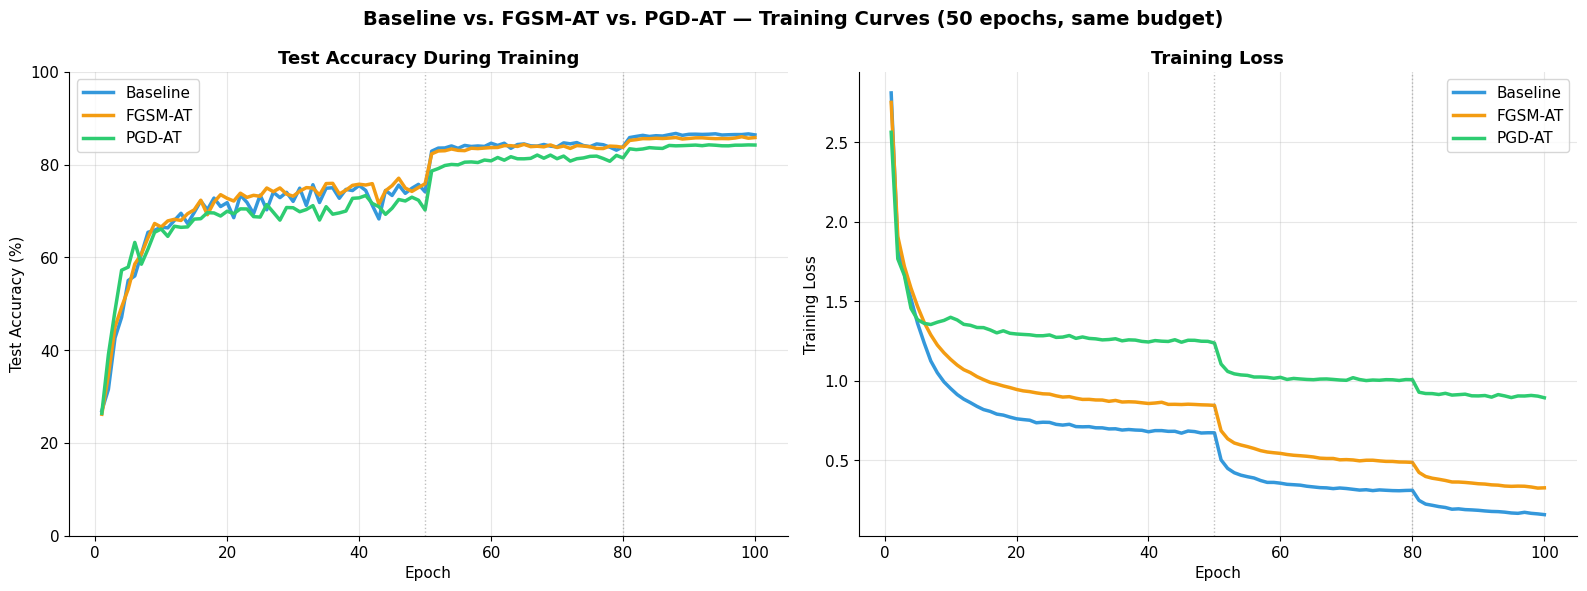

✓ Saved 'training_curves_comparison.png'


In [ ]:
# ── Training curves: all three models ────────────────────────────────────────
epochs_x = range(1, CFG["epochs"] + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for history, label, color in [(baseline_history, 'Baseline', PALETTE['Baseline']),
                               (fgsm_at_history,  'FGSM-AT',  PALETTE['FGSM-AT']),
                               (pgd_at_history,   'PGD-AT',   PALETTE['PGD-AT'])]:
    axes[0].plot(epochs_x, history['test_acc'],   label=label, color=color, lw=2.5)
    axes[1].plot(epochs_x, history['train_loss'], label=label, color=color, lw=2.5)

for ms in CFG["lr_milestones"]:
    axes[0].axvline(ms, color='grey', linestyle=':', alpha=0.5, lw=1)
    axes[1].axvline(ms, color='grey', linestyle=':', alpha=0.5, lw=1)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy During Training', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11); axes[0].set_ylim(0, 100)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Training Loss')
axes[1].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('Baseline vs. FGSM-AT vs. PGD-AT — Training Curves (50 epochs, same budget)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'training_curves_comparison.png'")


---
## 7. Results & Plots <a name="results"></a>

Full evaluation across all three models, all three attacks, and all epsilon values — repeated across three random seeds for mean ± std reporting.


In [ ]:
# ── Multi-seed evaluation ─────────────────────────────────────────────────────
print("Multi-seed evaluation (3 seeds × 3 models × 3 attacks × 10 epsilons)...")


all_records = []

for seed in CFG["seeds"]:
    print(f"\n{'='*55}\n  Seed {seed}\n{'='*55}")
    seed_everything(seed)

    m_base = build_resnet18(pretrained=True)
    train_model(m_base, trainloader, testloader, tag=f"Base-s{seed}")

    m_fgsm = build_resnet18(pretrained=True)
    adversarial_training(m_fgsm, trainloader, testloader,
                         attack='fgsm', tag=f"FGSM-AT-s{seed}")

    m_pgd = build_resnet18(pretrained=True)
    adversarial_training(m_pgd, trainloader, testloader,
                         attack='pgd', tag=f"PGD-AT-s{seed}")

    model_configs = [('Baseline', m_base), ('FGSM-AT', m_fgsm), ('PGD-AT', m_pgd)]
    attack_configs = [
        ('Clean',  None,                                          0.0),
        ('FGSM',   fgsm_attack,                                   None),
        ('PGD-5',  partial(pgd_attack, steps=CFG["pgd5_steps"]), None),
        ('PGD-20', partial(pgd_attack, steps=CFG["pgd20_steps"]),None),
    ]

    for model_name, mdl in model_configs:
        for atk_name, atk_fn, fixed_eps in attack_configs:
            epsilons_to_sweep = [0.0] if atk_name == 'Clean' else CFG["epsilons"]
            for eps in epsilons_to_sweep:
                actual_eps = fixed_eps if fixed_eps is not None else eps
                acc = evaluate_model(mdl, testloader,
                                     attack_fn=atk_fn, epsilon=actual_eps)
                all_records.append({
                    'Seed': seed, 'Model': model_name, 'Attack': atk_name,
                    'Epsilon': eps, 'Accuracy': acc
                })
                print(f"  {model_name:10s} | {atk_name:6s} ε={eps:.2f} → {acc:.1f}%")

raw_df = pd.DataFrame(all_records)
summary_df = (raw_df.groupby(['Model','Attack','Epsilon'])['Accuracy']
                    .agg(['mean','std']).reset_index()
                    .rename(columns={'mean':'AccMean','std':'AccStd'}))
raw_df.to_csv('results_raw.csv', index=False)
summary_df.to_csv('results_summary.csv', index=False)
print("\n✓ Results saved")


Multi-seed evaluation (3 seeds × 3 models × 3 attacks × 10 epsilons)...

  Seed 42


  [Base-s42] E01  loss=2.811  train=19.0%  test=26.9%  lr=0.10000


  [Base-s42] E05  loss=1.362  train=49.8%  test=55.0%  lr=0.10000


  [Base-s42] E10  loss=0.952  train=66.8%  test=66.5%  lr=0.10000


  [Base-s42] E15  loss=0.820  train=71.6%  test=69.7%  lr=0.10000


...

  [PGD-AT-s7] E80  loss=1.007  train=74.8%  test=81.3%  lr=0.00100


  [PGD-AT-s7] E85  loss=0.912  train=79.2%  test=83.7%  lr=0.00100


  [PGD-AT-s7] E90  loss=0.908  train=80.1%  test=84.1%  lr=0.00100


  [PGD-AT-s7] E95  loss=0.905  train=80.5%  test=83.9%  lr=0.00100


  [PGD-AT-s7] E100  loss=0.901  train=80.9%  test=84.1%  lr=0.00100
  Baseline   | Clean  ε=0.00 → 86.3%
  Baseline   | FGSM   ε=0.00 → 86.3%
  Baseline   | FGSM   ε=0.01 → 74.0%
  Baseline   | FGSM   ε=0.02 → 60.6%
  Baseline   | FGSM   ε=0.03 → 49.3%
  Baseline   | FGSM   ε=0.05 → 32.9%
  Baseline   | FGSM   ε=0.08 → 19.1%
  Baseline   | FGSM   ε=0.10 → 13.4%
  Baseline   | FGSM   ε=0.15 → 7.0%
  Baseline   | FGSM   ε=0.20 → 4.5%
  Baseline   | FGSM   ε=0.30 → 3.3%
  Baseline   | PGD-5  ε=0.00 → 86.3%
  Baseline   | PGD-5  ε=0.01 → 72.5%
  Baseline   | PGD-5  ε=0.02 → 54.7%
  Baseline   | PGD-5  ε=0.03 → 39.5%
  Baseline   | PGD-5  ε=0.05 → 17.2%
  Baseline   | PGD-5  ε=0.08 → 4.3%
  Baseline   | PGD-5  ε=0.10 → 1.4%
  Baseline   | PGD-5  ε=0.15 → 0.1%
  Baseline   | PGD-5  ε=0.20 → 0.0%
  Baseline   | PGD-5  ε=0.30 → 0.0%
  Baseline   | PGD-20 ε=0.00 → 86.3%
  Baseline   | PGD-20 ε=0.01 → 72.3%
  Baseline   | PGD-20 ε=0.02 → 53.7%
  Baseline   | PGD-20 ε=0.03 → 37.6%
  Baseline   | 

In [ ]:
# ── Final results table ───────────────────────────────────────────────────────
def get_acc(model_name, attack, eps):
    r = summary_df[(summary_df.Model==model_name) &
                   (summary_df.Attack==attack) &
                   (summary_df.Epsilon==eps)]
    if len(r):
        return r['AccMean'].values[0], r['AccStd'].values[0]
    return float('nan'), float('nan')

print("\n" + "="*80)
print(f"  FINAL RESULTS (mean ± std, {NUM_SEEDS} seeds, full test set)")
print("="*80)
print(f"  {'Model':<12} {'Clean':>10} {'FGSM ε=0.03':>14} {'PGD-5 ε=0.03':>14} {'PGD-20 ε=0.03':>15}")
print("-"*80)
for mname in ['Baseline','FGSM-AT','PGD-AT']:
    cl_m,  cl_s  = get_acc(mname, 'Clean',  0.0)
    fg_m,  fg_s  = get_acc(mname, 'FGSM',   0.03)
    p5_m,  p5_s  = get_acc(mname, 'PGD-5',  0.03)
    p20_m, p20_s = get_acc(mname, 'PGD-20', 0.03)
    print(f"  {mname:<12} "
          f"{cl_m:>6.1f}±{cl_s:<4.1f} "
          f"{fg_m:>7.1f}±{fg_s:<4.1f} "
          f"{p5_m:>7.1f}±{p5_s:<4.1f} "
          f"{p20_m:>7.1f}±{p20_s:<4.1f}")
print("="*80)


fgsm_pgd20 = get_acc('FGSM-AT', 'PGD-20', 0.03)[0]
pgd_pgd20  = get_acc('PGD-AT',  'PGD-20', 0.03)[0]
print(f"\nPGD-AT vs FGSM-AT gap under PGD-20: {pgd_pgd20 - fgsm_pgd20:+.1f}%")



  FINAL RESULTS (mean ± std, 3 seeds, full test set)
  Model             Clean    FGSM ε=0.03   PGD-5 ε=0.03   PGD-20 ε=0.03
--------------------------------------------------------------------------------
  Baseline       86.4±0.1     48.7±0.5     38.4±0.9     36.4±1.1 
  FGSM-AT        85.8±0.2     70.3±0.3     68.2±0.3     67.9±0.4 
  PGD-AT         84.2±0.4     71.6±0.7     70.4±0.8     70.2±0.8 

PGD-AT vs FGSM-AT gap under PGD-20: +2.3%


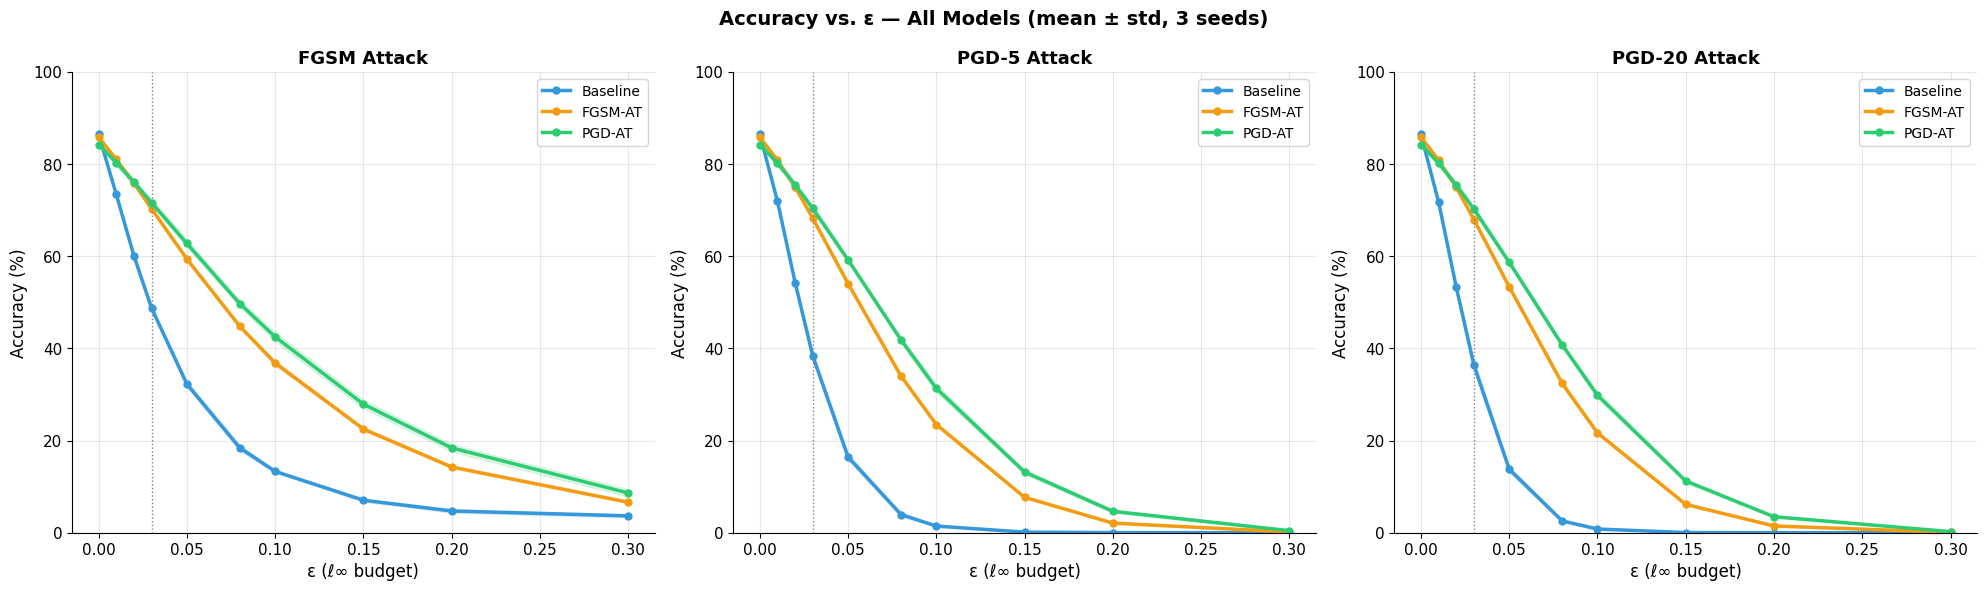

✓ Saved 'accuracy_vs_epsilon_all_models.png'


In [ ]:
# ── Plot 1: Accuracy vs ε — all models, all attacks ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, atk_name in zip(axes, ['FGSM', 'PGD-5', 'PGD-20']):
    for mname in ['Baseline', 'FGSM-AT', 'PGD-AT']:
        d = summary_df[(summary_df.Model==mname) &
                       (summary_df.Attack==atk_name)].sort_values('Epsilon')
        if d.empty: continue
        ax.plot(d['Epsilon'], d['AccMean'], color=PALETTE[mname],
                linewidth=2.5, marker='o', markersize=5, label=mname)
        ax.fill_between(d['Epsilon'],
                        d['AccMean'] - d['AccStd'],
                        d['AccMean'] + d['AccStd'],
                        alpha=0.15, color=PALETTE[mname])
    ax.set_xlabel('ε (ℓ∞ budget)', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'{atk_name} Attack', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10); ax.set_ylim(0, 100)
    ax.axvline(CFG["eps_train"], color='grey', linestyle=':', lw=1)

plt.suptitle(f'Accuracy vs. ε — All Models (mean ± std, {NUM_SEEDS} seeds)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_vs_epsilon_all_models.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved 'accuracy_vs_epsilon_all_models.png'")


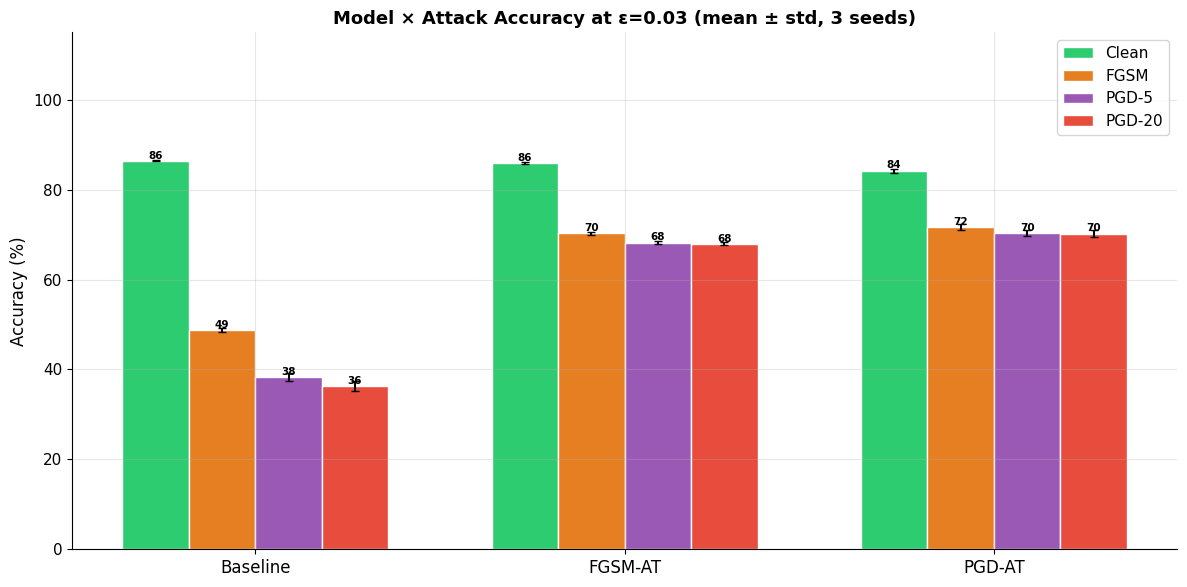

✓ Saved 'grouped_bar_accuracy.png'


In [ ]:
# ── Plot 2: Grouped bar chart at ε=0.03 ──────────────────────────────────────
eps_fixed  = 0.03
model_names = ['Baseline', 'FGSM-AT', 'PGD-AT']
attacks    = ['Clean', 'FGSM', 'PGD-5', 'PGD-20']
atk_colors = [PALETTE['Clean'], PALETTE['FGSM'], PALETTE['PGD-5'], PALETTE['PGD-20']]

x = np.arange(len(model_names))
w = 0.18
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]

fig, ax = plt.subplots(figsize=(12, 6))
for atk, color, off in zip(attacks, atk_colors, offsets):
    means = [get_acc(m, atk, 0.0 if atk=='Clean' else eps_fixed)[0] for m in model_names]
    stds  = [get_acc(m, atk, 0.0 if atk=='Clean' else eps_fixed)[1] for m in model_names]
    bars  = ax.bar(x + off, means, w, label=atk, color=color,
                   edgecolor='white', yerr=stds, capsize=3)
    for b, v in zip(bars, means):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f'{v:.0f}', ha='center', fontsize=7.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.set_title(f'Model × Attack Accuracy at ε={eps_fixed} (mean ± std, {NUM_SEEDS} seeds)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('grouped_bar_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'grouped_bar_accuracy.png'")


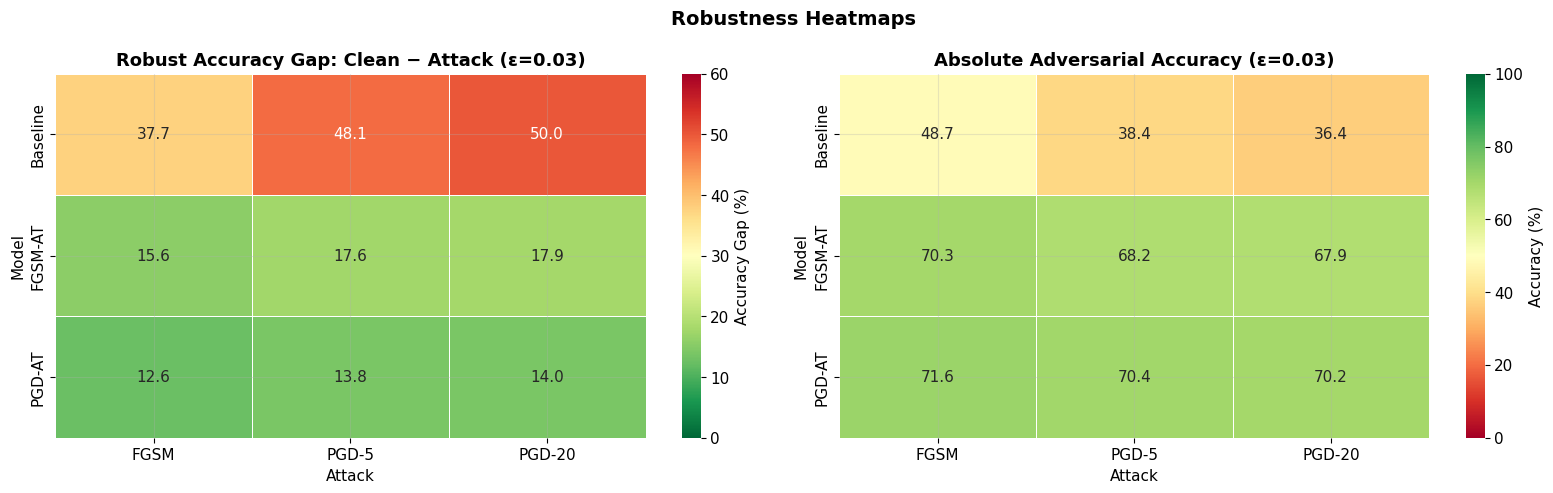

✓ Saved 'robustness_heatmaps.png'


In [ ]:
# ── Plot 3: Robustness heatmaps ───────────────────────────────────────────────
eps_fixed   = 0.03
model_names = ['Baseline', 'FGSM-AT', 'PGD-AT']
attacks     = ['FGSM', 'PGD-5', 'PGD-20']

gap_data = {}
abs_data = {}
for mname in model_names:
    clean_m = get_acc(mname, 'Clean', 0.0)[0]
    gap_data[mname] = {atk: clean_m - get_acc(mname, atk, eps_fixed)[0] for atk in attacks}
    abs_data[mname] = {atk: get_acc(mname, atk, eps_fixed)[0] for atk in attacks}

gap_df = pd.DataFrame(gap_data).T
abs_df = pd.DataFrame(abs_data).T

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(gap_df, annot=True, fmt='.1f', cmap='RdYlGn_r', vmin=0, vmax=60,
            ax=axes[0], cbar_kws={'label': 'Accuracy Gap (%)'}, linewidths=0.5)
axes[0].set_title(f'Robust Accuracy Gap: Clean − Attack (ε={eps_fixed})',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attack'); axes[0].set_ylabel('Model')

sns.heatmap(abs_df, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100,
            ax=axes[1], cbar_kws={'label': 'Accuracy (%)'}, linewidths=0.5)
axes[1].set_title(f'Absolute Adversarial Accuracy (ε={eps_fixed})',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attack'); axes[1].set_ylabel('Model')

plt.suptitle('Robustness Heatmaps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('robustness_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'robustness_heatmaps.png'")


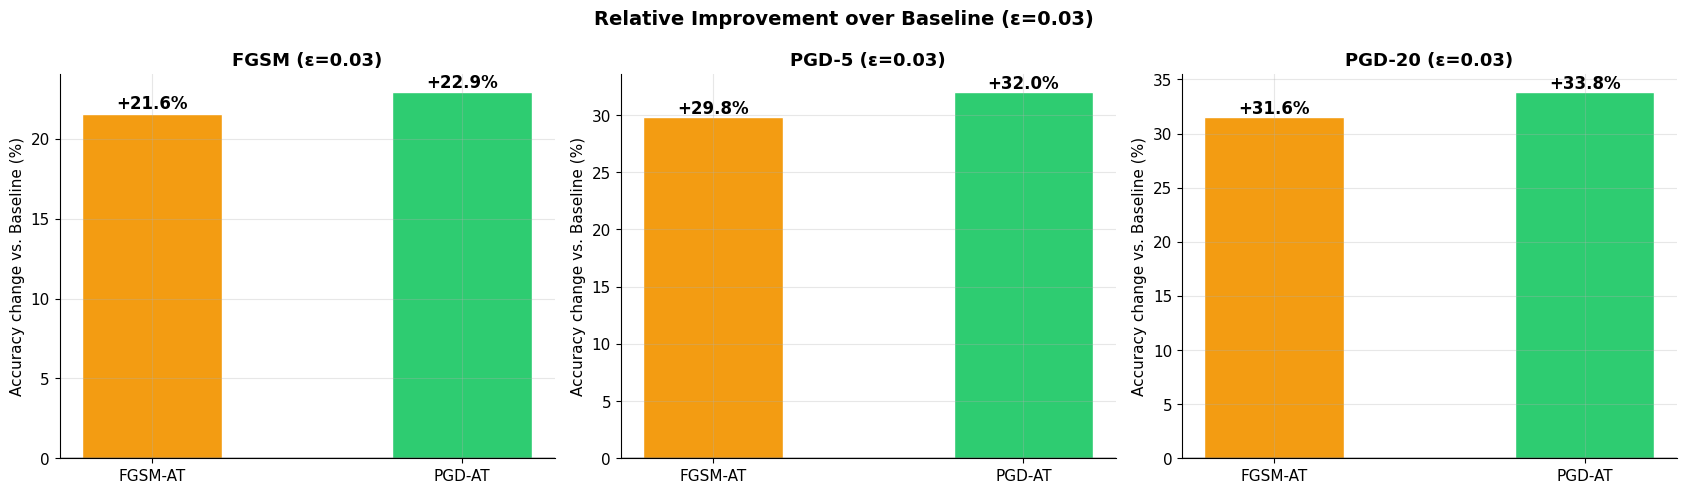

✓ Saved 'relative_improvement.png'


In [ ]:
# ── Plot 4: Relative improvement over baseline ───────────────────────────────
eps_fixed = 0.03
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, atk in zip(axes, ['FGSM', 'PGD-5', 'PGD-20']):
    base_v = get_acc('Baseline', atk, eps_fixed)[0]
    rel_fgsm = get_acc('FGSM-AT', atk, eps_fixed)[0] - base_v
    rel_pgd  = get_acc('PGD-AT',  atk, eps_fixed)[0] - base_v

    bars = ax.bar(['FGSM-AT', 'PGD-AT'], [rel_fgsm, rel_pgd],
                  color=[PALETTE['FGSM-AT'], PALETTE['PGD-AT']],
                  edgecolor='white', width=0.45)
    for b, v in zip(bars, [rel_fgsm, rel_pgd]):
        ax.text(b.get_x()+b.get_width()/2,
                b.get_height() + (0.3 if v >= 0 else -1.5),
                f'{v:+.1f}%', ha='center', fontsize=12, fontweight='bold')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'{atk} (ε={eps_fixed})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy change vs. Baseline (%)')

plt.suptitle(f'Relative Improvement over Baseline (ε={eps_fixed})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('relative_improvement.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'relative_improvement.png'")


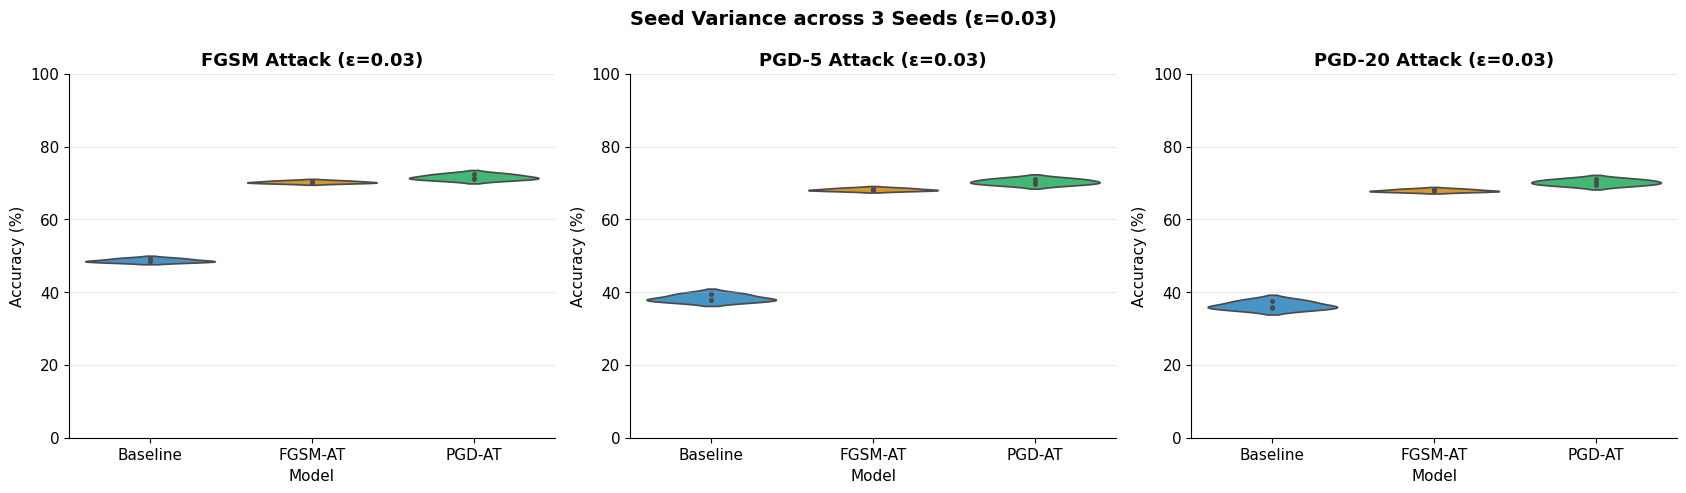

✓ Saved 'seed_variance_violin.png'


In [ ]:
# ── Plot 5: Seed variance violin plots ───────────────────────────────────────
eps_fixed = 0.03
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, atk in zip(axes, ['FGSM', 'PGD-5', 'PGD-20']):
    d = raw_df[(raw_df['Attack']==atk) & (raw_df['Epsilon']==eps_fixed)]
    order = ['Baseline', 'FGSM-AT', 'PGD-AT']
    sns.violinplot(data=d, x='Model', y='Accuracy', order=order,
                   palette={m: PALETTE[m] for m in order}, inner='point', ax=ax)
    ax.set_title(f'{atk} Attack (ε={eps_fixed})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy (%)'); ax.set_xlabel('Model')
    ax.set_ylim(0, 100)

plt.suptitle(f'Seed Variance across {NUM_SEEDS} Seeds (ε={eps_fixed})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('seed_variance_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'seed_variance_violin.png'")


Optional epoch sweep: 10 / 30 / 50 epochs (Baseline model)...


  [Baseline-10ep] E01  loss=2.811  train=19.0%  test=26.9%  lr=0.10000


  [Baseline-10ep] E05  loss=1.362  train=49.8%  test=55.0%  lr=0.10000


  [Baseline-10ep] E10  loss=0.952  train=66.8%  test=66.5%  lr=0.10000
  10 epochs → clean=66.5%  FGSM=39.3%  PGD-20=35.5%


  [Baseline-50ep] E01  loss=2.545  train=22.6%  test=37.5%  lr=0.10000


...

  [Baseline-100ep] E80  loss=0.305  train=89.4%  test=83.2%  lr=0.00100


  [Baseline-100ep] E85  loss=0.196  train=93.2%  test=86.5%  lr=0.00100


  [Baseline-100ep] E90  loss=0.178  train=93.9%  test=86.7%  lr=0.00100


  [Baseline-100ep] E95  loss=0.166  train=94.2%  test=86.4%  lr=0.00100


  [Baseline-100ep] E100  loss=0.157  train=94.4%  test=86.4%  lr=0.00100
  100 epochs → clean=86.4%  FGSM=49.3%  PGD-20=36.7%


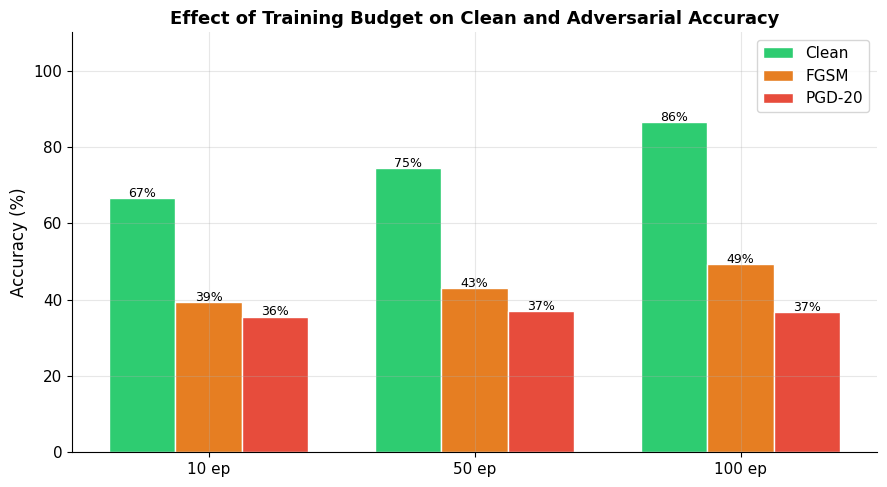

✓ Saved 'epoch_sweep.png'


In [ ]:
import torchvision.models as models

print("Optional epoch sweep: 10 / 30 / 50 epochs (Baseline model)...")
seed_everything(CFG["seeds"][0])
epoch_sweep_results = []

for n_epochs in CFG["epoch_sweep"]:
    m_sw = build_resnet18(pretrained=True)
    train_model(m_sw, trainloader, testloader, epochs=n_epochs,
                tag=f"Baseline-{n_epochs}ep")
    cl_acc    = evaluate_model(m_sw, testloader)
    fgsm_sw   = evaluate_model(m_sw, testloader,
                                attack_fn=fgsm_attack, epsilon=CFG["eps_train"])
    pgd20_sw  = evaluate_model(m_sw, testloader,
                                attack_fn=partial(pgd_attack, steps=CFG["pgd20_steps"]),
                                epsilon=CFG["eps_train"])
    epoch_sweep_results.append({'Epochs': n_epochs, 'Clean': cl_acc,
                                  'FGSM': fgsm_sw, 'PGD-20': pgd20_sw})
    print(f"  {n_epochs} epochs → clean={cl_acc:.1f}%  FGSM={fgsm_sw:.1f}%  PGD-20={pgd20_sw:.1f}%")

sw_df = pd.DataFrame(epoch_sweep_results)
fig, ax = plt.subplots(figsize=(9, 5))
x_sw = np.arange(len(CFG["epoch_sweep"]))
w_sw = 0.25
for i, (col, color) in enumerate([('Clean', PALETTE['Clean']),
                                    ('FGSM',  PALETTE['FGSM']),
                                    ('PGD-20',PALETTE['PGD-20'])]):
    bars = ax.bar(x_sw + i*w_sw, sw_df[col], w_sw, label=col,
                  color=color, edgecolor='white')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                f'{b.get_height():.0f}%', ha='center', fontsize=9)
ax.set_xticks(x_sw + w_sw)
ax.set_xticklabels([f'{e} ep' for e in CFG["epoch_sweep"]])
ax.set_ylabel('Accuracy (%)', fontsize=12); ax.set_ylim(0, 110)
ax.set_title('Effect of Training Budget on Clean and Adversarial Accuracy',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('epoch_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'epoch_sweep.png'")


In [ ]:
# ── Final file manifest ────────────────────────────────────────────────────────
generated_files = [
    'baseline_model.pth', 'fgsm_at_model.pth', 'pgd_at_model.pth',
    'results_raw.csv', 'results_summary.csv',
    'dataset_samples.png',
    'baseline_training_curves.png',
    'accuracy_vs_epsilon_baseline.png',
    'attack_strength_ladder.png',
    'clean_vs_adversarial.png',
    'failure_cases_pgd20.png',
    'confusion_matrix.png',
    'training_curves_comparison.png',
    'accuracy_vs_epsilon_all_models.png',
    'grouped_bar_accuracy.png',
    'robustness_heatmaps.png',
    'relative_improvement.png',
    'seed_variance_violin.png',
    'epoch_sweep.png',
]

print("\nGENERATED FILES")
print("=" * 60)
for f in generated_files:
    if os.path.exists(f):
        print(f"  ✓ {f:<45} {os.path.getsize(f)/1024:.1f} KB")
    else:
        print(f"  ✗ {f}  (run all cells to generate)")



GENERATED FILES
  ✓ baseline_model.pth                            43756.1 KB
  ✓ fgsm_at_model.pth                             43756.0 KB
  ✓ pgd_at_model.pth                              43755.9 KB
  ✓ results_raw.csv                               7.7 KB
  ✓ results_summary.csv                           4.9 KB
  ✓ dataset_samples.png                           240.0 KB
  ✓ baseline_training_curves.png                  130.1 KB
  ✓ accuracy_vs_epsilon_baseline.png              134.3 KB
  ✓ attack_strength_ladder.png                    74.0 KB
  ✓ clean_vs_adversarial.png                      205.6 KB
  ✓ failure_cases_pgd20.png                       113.2 KB
  ✓ confusion_matrix.png                          213.0 KB
  ✓ training_curves_comparison.png                160.6 KB
  ✓ accuracy_vs_epsilon_all_models.png            304.4 KB
  ✓ grouped_bar_accuracy.png                      49.2 KB
  ✓ robustness_heatmaps.png                       88.7 KB
  ✓ relative_improvement.png            